In [1]:
import sys, os
import re
import gc
import glob
import pandas as pd
import ast
import itertools
import numpy as np
from pathlib import Path

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
from tqdm.notebook import tqdm

tqdm.pandas()

In [4]:
import warnings
warnings.filterwarnings("ignore")

### Loading package

In [5]:
import sys
from pathlib import Path

here_path = Path().resolve()
repo_path = here_path.parents[1]
sys.path.append(str(repo_path))

In [6]:
from py.utils import verifyDir,verifyFile

In [7]:
from py.config import Config

cfg = Config()

np.random.seed(cfg.RANDOM_STATE)
cfg.DATA_PATH, cfg.MODEL_PATH

('/media/felipe/DATA21/datasets/', '/media/felipe/DATA21/models/')

### Loading data

In [8]:
#DATA_ANALYSED = "PostCog_2023-12-15"
DATA_ANALYSED = "PostCog_2024-06-14"

In [9]:
DATA_PATH=f"{cfg.DATA_PATH}postcog/"
CSV_PATH = f"{DATA_PATH}/csv/"
THREADS_PROCESSED = f"{CSV_PATH}/topics/{cfg.TOPIC_SEARCH}/"

In [10]:
verifyDir(THREADS_PROCESSED)

In [11]:
postcog_df = pd.read_csv(f"{CSV_PATH}{DATA_ANALYSED}.csv", sep=",", low_memory=False)
postcog_df = postcog_df[~postcog_df["content"].isna()]
postcog_df = postcog_df[~postcog_df["timestamp"].isna()]
postcog_df.reset_index(drop=True, inplace=True)
postcog_df.sort_values(by=["timestamp"], inplace=True)
postcog_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15645 entries, 0 to 15644
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          15645 non-null  int64  
 1   thread_id   15645 non-null  int64  
 2   board_id    15645 non-null  int64  
 3   site_id     15645 non-null  int64  
 4   content     15645 non-null  str    
 5   timestamp   15645 non-null  str    
 6   threadname  15644 non-null  str    
 7   boardname   15523 non-null  str    
 8   sitename    15645 non-null  str    
 9   intent      9801 non-null   str    
 10  posttype    9801 non-null   str    
 11  crime_type  15645 non-null  str    
 12  creator_id  14681 non-null  float64
 13  creator     15587 non-null  str    
dtypes: float64(1), int64(4), str(9)
memory usage: 32.2 MB


### Websites

In [12]:
postcog_df["post_time"] = postcog_df["timestamp"].apply(lambda x: x.split("T")[0])
postcog_df

,id,thread_id,board_id,site_id,content,timestamp,threadname,boardname,sitename,intent,posttype,crime_type,creator_id,creator,post_time
0,121433,111536,32,1032,Para una introducción a lo que se trata en est...,2004-01-08T23:13:00.000Z,<-!-> FAQ - Biblioteca - Recopilatorio de Shel...,Bugs y Exploits,Elhacker,NaN,NaN,not criminal,333.0,Rojodos,2004-01-08
1,182204,36767,44,1032,pues me he encontrado el texto en cual se demu...,2004-08-08T02:41:00.000Z,¿Como puedo saber si un sistema Linux ha sido ...,Hacking,Elhacker,NaN,NaN,not criminal,NaN,zhyzura,2004-08-08
2,96068,12520,16,1030,Topic : phpBB 2.0.19 XSS\n\nSecurityAlert Id :...,2006-01-06T04:50:00.000Z,Новая XSS на форуме phpBB 2.0.19,Уязвимости CMS/форумов,Antichat,NaN,NaN,not criminal,18692.0,NeMiNeM,2006-01-06
3,181336,22457,189,1030,karocia jest ujazvmast\nFlashChat Adminips.PHP...,2006-08-10T19:41:00.000Z,flash chat help,Песочница,Antichat,NaN,NaN,not criminal,25174.0,jusuf,2006-08-10
4,67937,11334,2,1034,лыуди я прасканировал один адрес с х-пидер и о...,2006-09-03T11:58:40.000Z,Dos ataka,Уязвимости web-приложений,XSS Forum,NaN,NaN,not criminal,5160.0,Shadow,2006-09-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15640,62375270,6269861,5,1000,That's insane but to be expected for such prog...,2024-05-21T04:11:39.000Z,CVE-2023-38831-winrar-exploit,Coders Lounge,Hack Forums,neutral,infoRequest,not criminal,4402880.0,Osiris▲,2024-05-21
15641,62375821,6271584,89,1000,GitHub has rolled out fixes to address a maxim...,2024-05-21T17:14:53.000Z,Critical GitHub Enterprise Server Flaw Allows ...,News and Happenings,Hack Forums,neutral,infoRequest,not criminal,5525037.0,MetaMask,2024-05-21
15642,62376145,6271573,4,1000,Then study pentesting and focus on targeting w...,2024-05-22T01:25:00.000Z,How to start hacking,Beginner Hacking,Hack Forums,neutral,infoRequest,not criminal,5502421.0,happygonutty,2024-05-22
15643,158241,158241,120,1027,GitHub ha corregido una vulnerabilidad de omis...,2024-05-22T19:13:17.000Z,GitHub advierte sobre falla de autenticación S...,Noticias Informáticas,Underc0de,NaN,NaN,not criminal,83483.0,Dragora,2024-05-22


 #### Temporal data

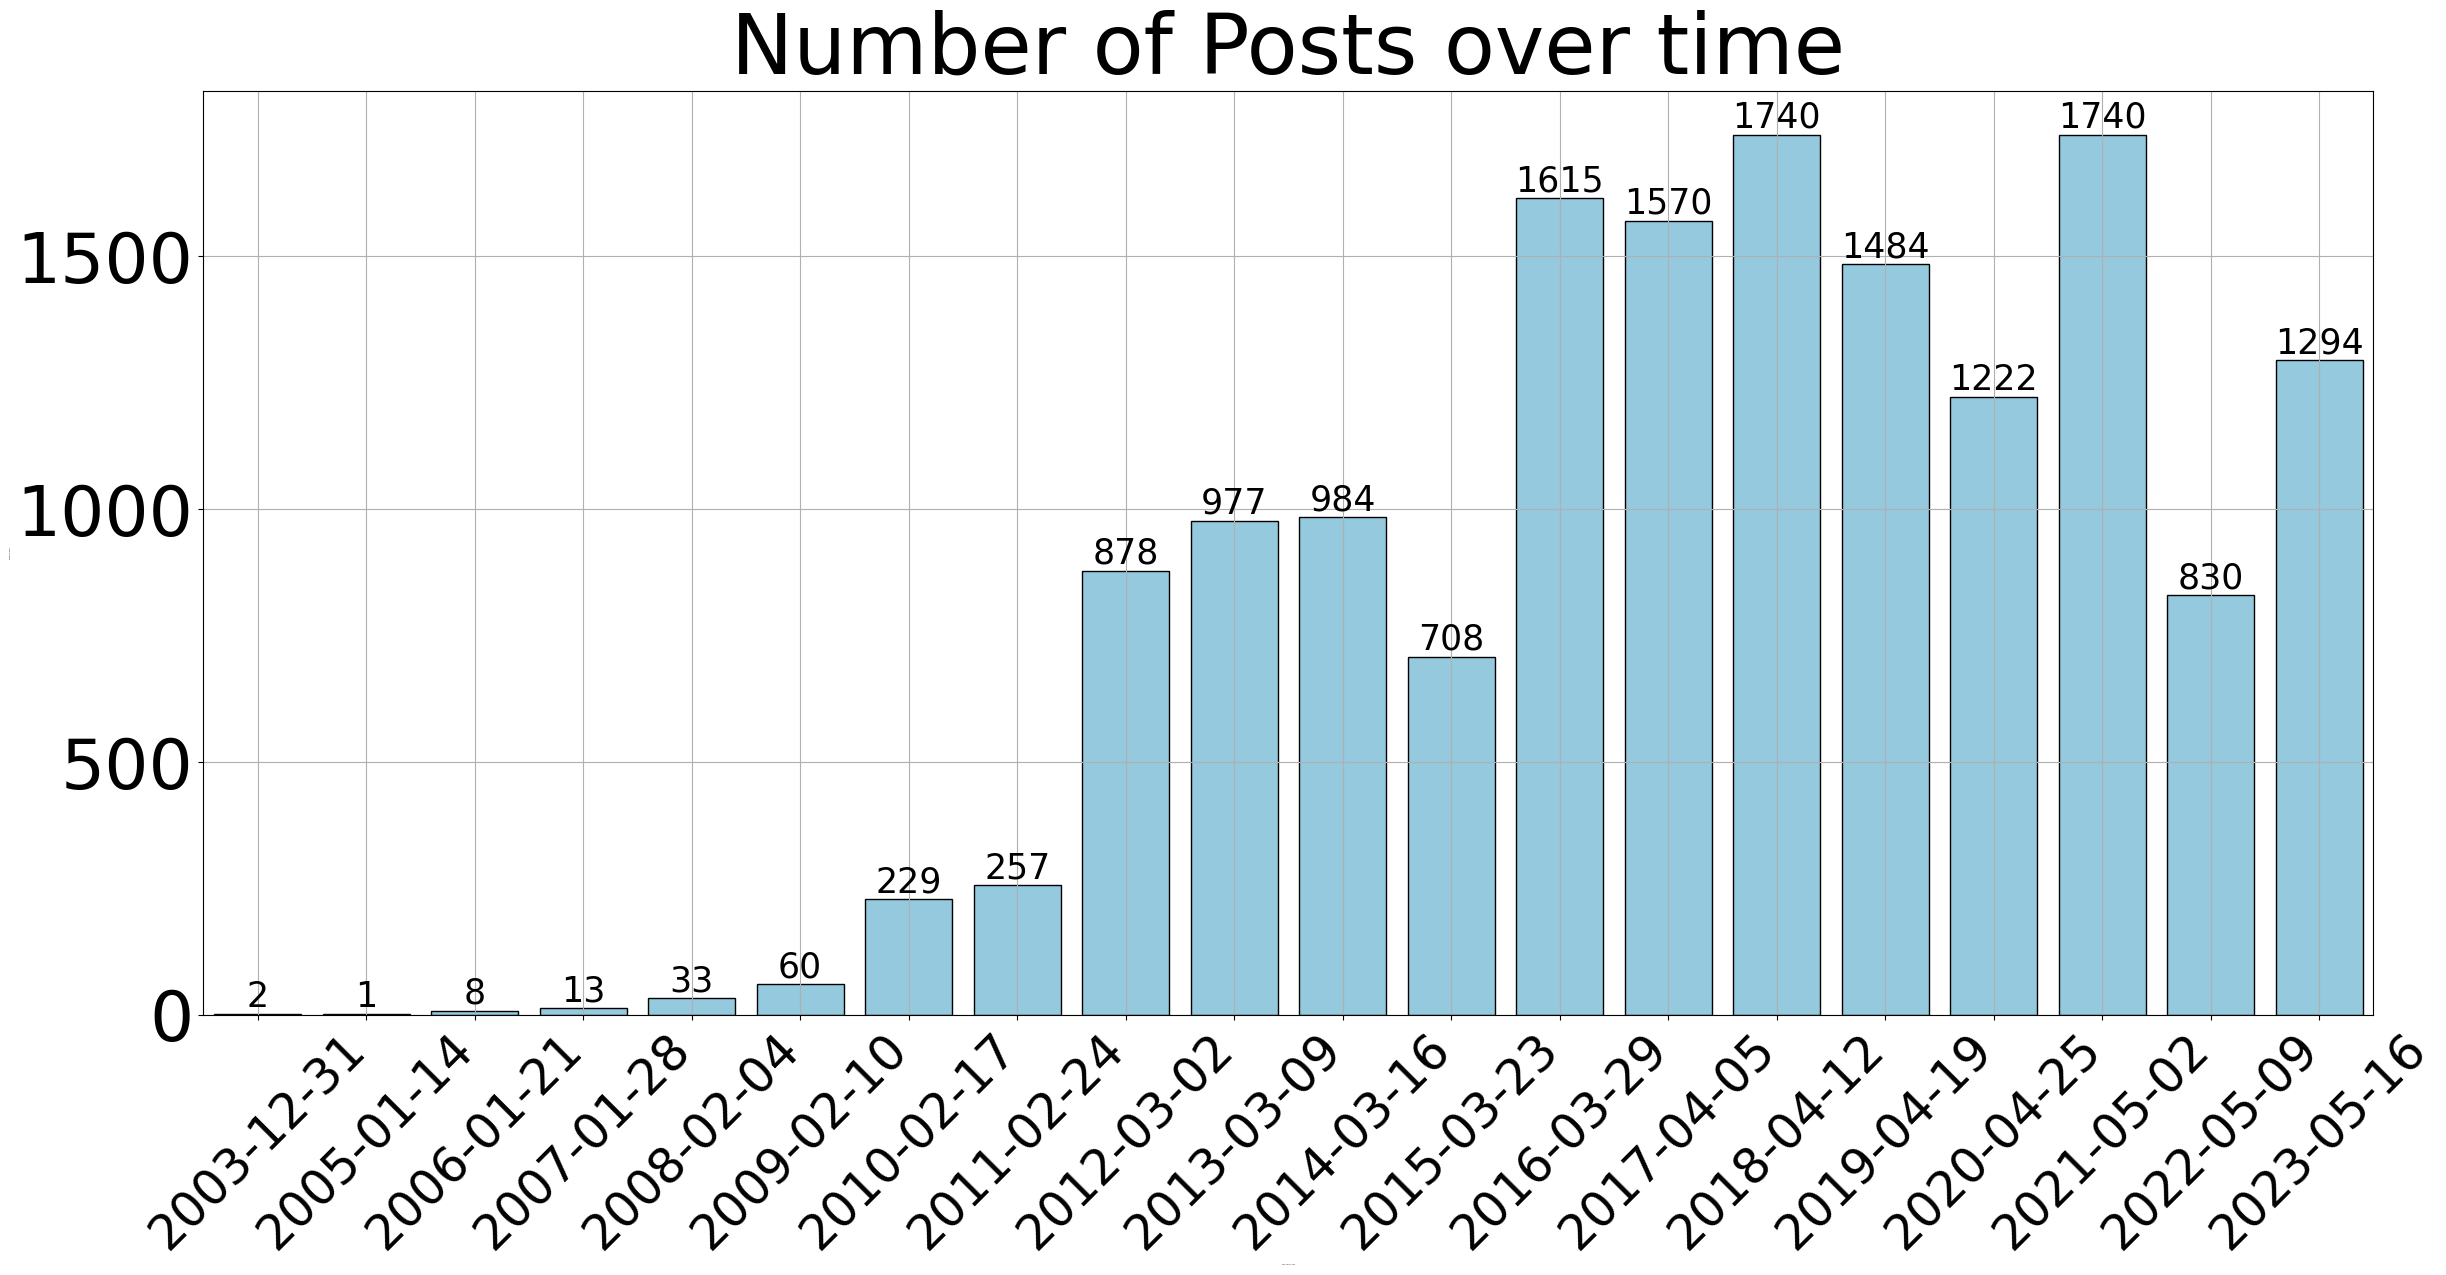

In [13]:
time_df = pd.pivot_table(postcog_df,
              index=["post_time"],
              values=["content"],
              aggfunc={
                  "content":len
              }).reset_index()
time_df['post_time'] = pd.to_datetime(time_df['post_time'])
min_date = time_df['post_time'].min()
max_date = time_df['post_time'].max()

bins = pd.date_range(start=min_date, end=max_date, freq='ME')
# Digitize the post times to get bin indices
time_df['bin'] = pd.cut(time_df['post_time'], bins=20)
# Aggregate the mentions by bin
mentions_per_bin = time_df.groupby('bin')['content'].sum().reset_index()

# Prepare data for plotting
mentions_per_bin['bin'] = mentions_per_bin['bin'].apply(lambda x: x.left.date())

_, ax = plt.subplots(figsize=(28,12), nrows=1, ncols=1, sharex=False, sharey=False)

sns_fig = sns.barplot(data=mentions_per_bin, 
                      x=mentions_per_bin.columns[0], 
                      y=mentions_per_bin.columns[1], 
                      ax=ax,
                      color="skyblue",
                      edgecolor='black')

# sns_fig.set_title(f'Number of Posts between {str(min_date).split(" ")[0]} and {str(max_date).split(" ")[0]}', fontsize=60)
sns_fig.set_title(f'Number of Posts over time', fontsize=60)
sns_fig.set_ylabel('Number of posts', fontsize=0)
sns_fig.set_xlabel('Post creation time', fontsize=0)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=45, labelsize=35)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='y', labelsize=50)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%0.0f', fontsize=25,rotation=0)

# add a space on y for the annotations
#sns_fig.margins(x=0.1)
ax.grid(True)

#### Hack Forums

In [14]:
hf_df = postcog_df[(postcog_df["sitename"]=="Hack Forums")].copy()
hf_df

,id,thread_id,board_id,site_id,content,timestamp,threadname,boardname,sitename,intent,posttype,crime_type,creator_id,creator,post_time
15,9282,3205,4,1000,"I found these, but how do I exploit them? \n\n...",2007-12-15T23:25:00.000Z,"Almost there, just need a little help. :)",Beginner Hacking,Hack Forums,neutral,requestX,not criminal,1419.0,sup3r501d13r,2007-12-15
16,35602,9393,4,1000,you should already have this site in your book...,2008-01-04T14:44:00.000Z,SMF 1.1.2 Exploit,Beginner Hacking,Hack Forums,neutral,offerX,not criminal,641.0,Kuroda_Shun,2008-01-04
18,38831,9768,4,1000,There is a really good easy to use program tha...,2008-01-15T15:22:00.000Z,College see other computers?,Beginner Hacking,Hack Forums,positive,comment,access to systems/sql injection,641.0,Kuroda_Shun,2008-01-15
19,39276,9825,13,1000,Please use these sites for some of your querie...,2008-01-16T22:00:00.000Z,Search CVE and CCE Vulnerability Database,Computer Protection and Security Alerts,Hack Forums,neutral,comment,not criminal,641.0,Kuroda_Shun,2008-01-16
20,44806,10479,25,1000,HACKER SAFE certification is achieved by passi...,2008-01-30T20:19:00.000Z,Hacker Safe logo,The Lounge,Hack Forums,positive,tutorial,access to systems/sql injection,4694.0,bsdpunk,2008-01-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15636,62371954,6269861,5,1000,Don't apologize; half of the people on this fo...,2024-05-18T01:28:00.000Z,CVE-2023-38831-winrar-exploit,Coders Lounge,Hack Forums,neutral,comment,not criminal,5525902.0,Evolution Zero,2024-05-18
15639,62375078,6269861,5,1000,great thing about this vuln is winzip dosnt ha...,2024-05-21T00:11:39.000Z,CVE-2023-38831-winrar-exploit,Coders Lounge,Hack Forums,neutral,comment,not criminal,5396825.0,littlephish420,2024-05-21
15640,62375270,6269861,5,1000,That's insane but to be expected for such prog...,2024-05-21T04:11:39.000Z,CVE-2023-38831-winrar-exploit,Coders Lounge,Hack Forums,neutral,infoRequest,not criminal,4402880.0,Osiris▲,2024-05-21
15641,62375821,6271584,89,1000,GitHub has rolled out fixes to address a maxim...,2024-05-21T17:14:53.000Z,Critical GitHub Enterprise Server Flaw Allows ...,News and Happenings,Hack Forums,neutral,infoRequest,not criminal,5525037.0,MetaMask,2024-05-21


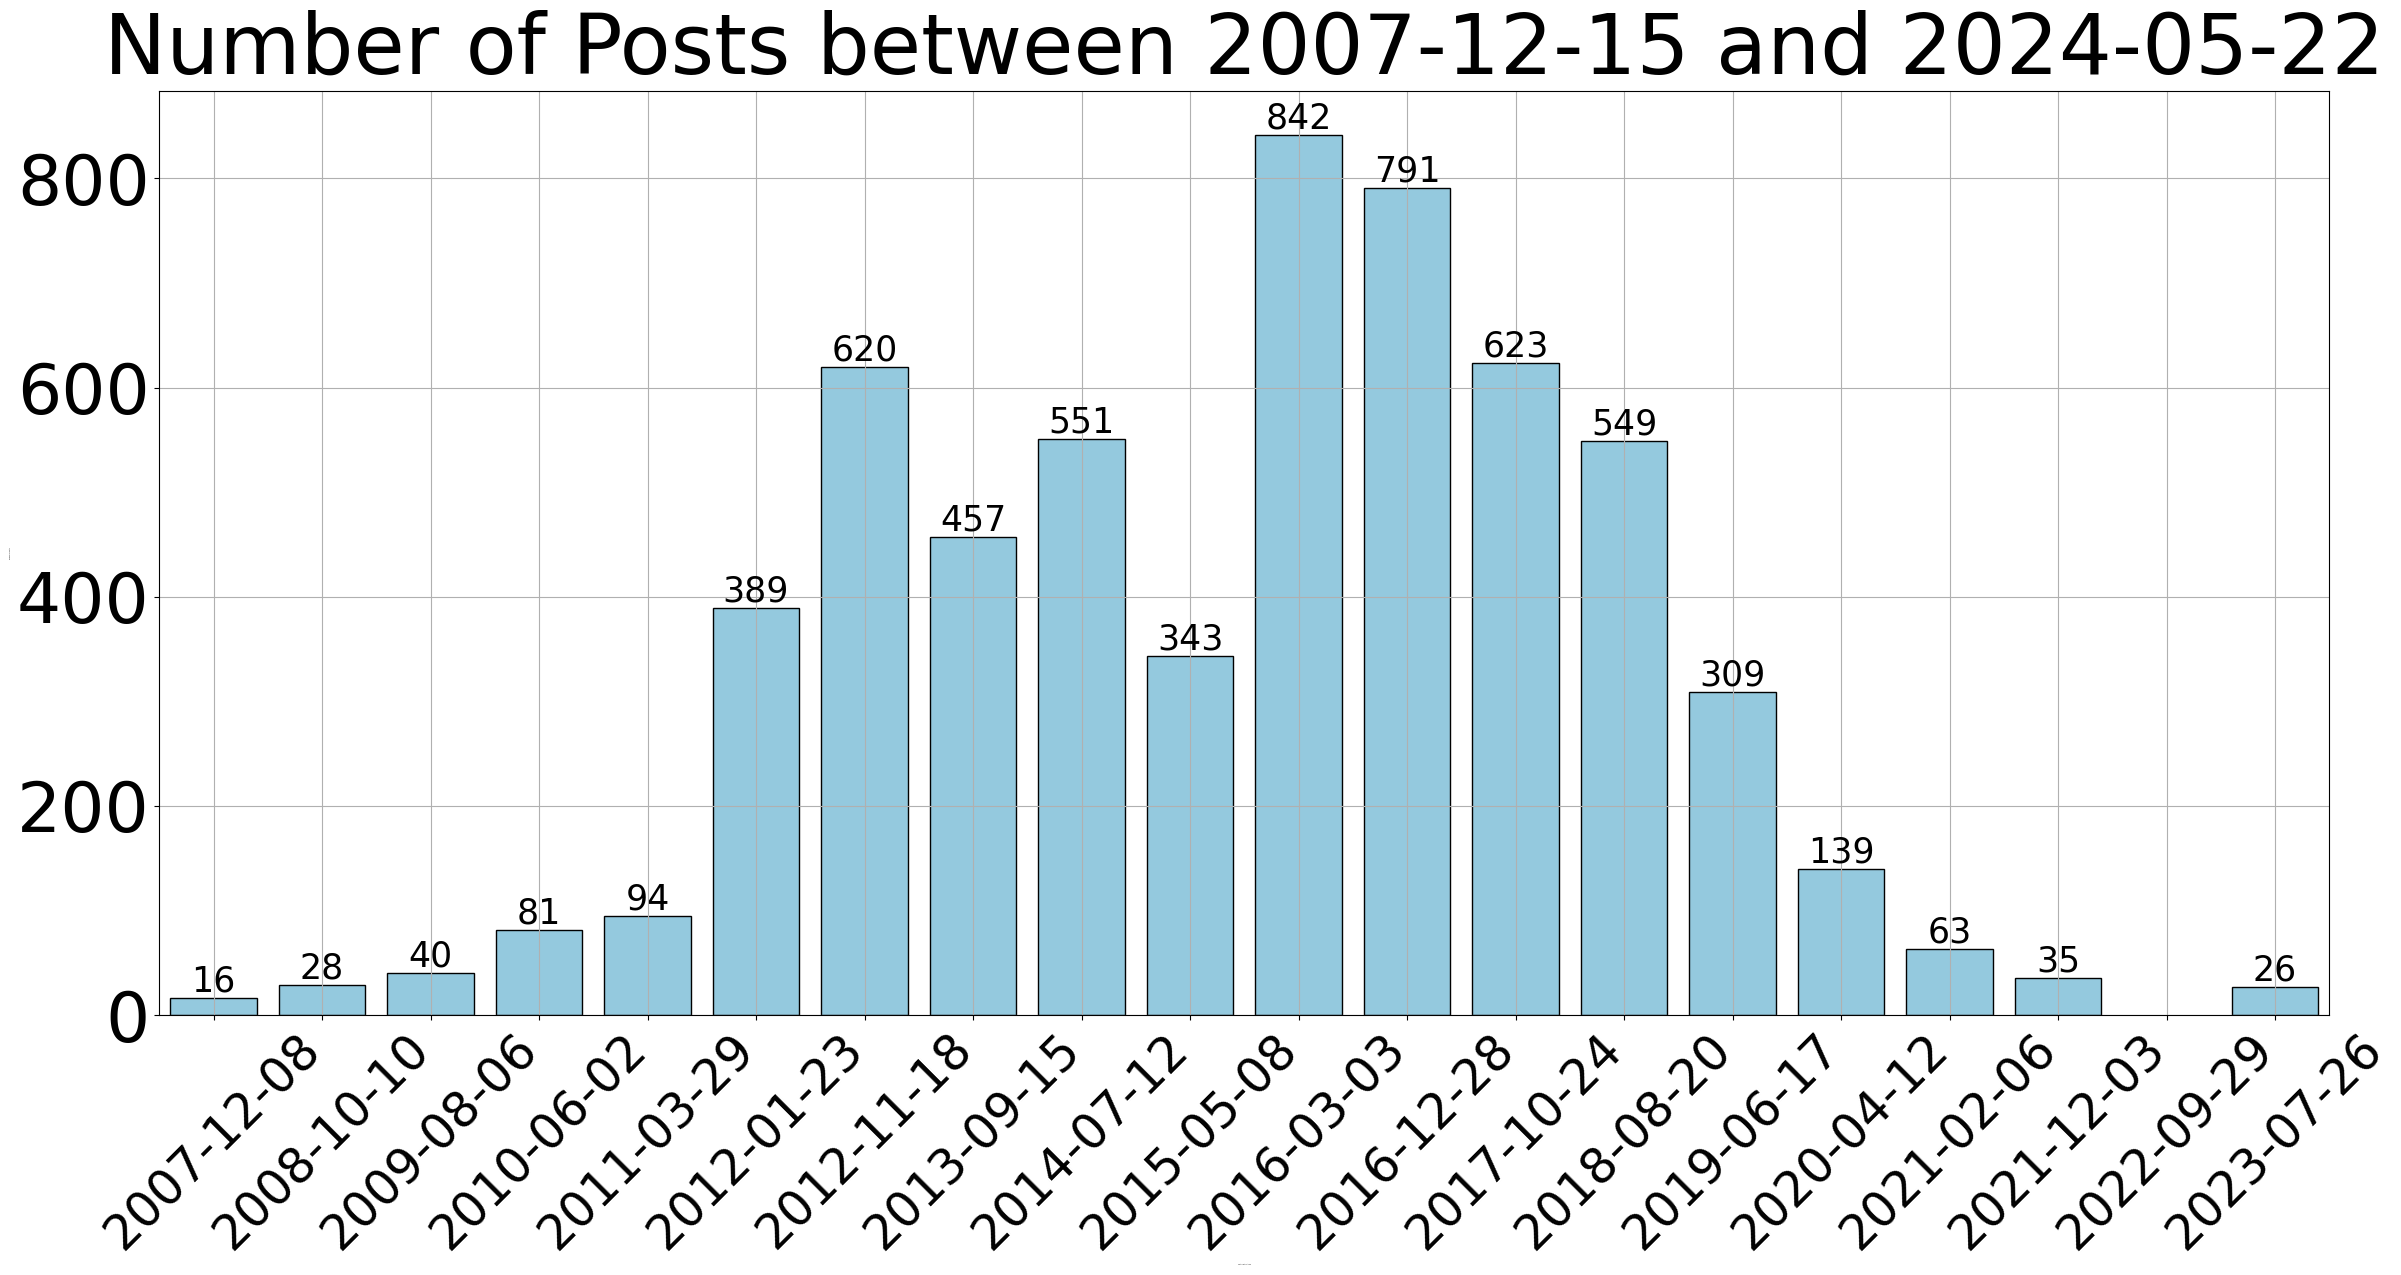

In [15]:
time_df = pd.pivot_table(hf_df,
              index=["post_time"],
              values=["content"],
              aggfunc={
                  "content":len
              }).reset_index()
time_df['post_time'] = pd.to_datetime(time_df['post_time'])
min_date = time_df['post_time'].min()
max_date = time_df['post_time'].max()

bins = pd.date_range(start=min_date, end=max_date, freq='ME')
# Digitize the post times to get bin indices
time_df['bin'] = pd.cut(time_df['post_time'], bins=20)
# Aggregate the mentions by bin
mentions_per_bin = time_df.groupby('bin')['content'].sum().reset_index()

# Prepare data for plotting
mentions_per_bin['bin'] = mentions_per_bin['bin'].apply(lambda x: x.left.date())

_, ax = plt.subplots(figsize=(28,12), nrows=1, ncols=1, sharex=False, sharey=False)

sns_fig = sns.barplot(data=mentions_per_bin, 
                      x=mentions_per_bin.columns[0], 
                      y=mentions_per_bin.columns[1], 
                      ax=ax,
                      color="skyblue",
                      edgecolor='black')

sns_fig.set_title(f'Number of Posts between {str(min_date).split(" ")[0]} and {str(max_date).split(" ")[0]}', fontsize=60)
sns_fig.set_ylabel('Number of posts', fontsize=0)
sns_fig.set_xlabel('Post creation time', fontsize=0)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=45, labelsize=35)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='y', labelsize=50)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%0.0f', fontsize=25,rotation=0)

# add a space on y for the annotations
#sns_fig.margins(x=0.1)
ax.grid(True)

#### Counting threads, borads, and posts

In [16]:
pd.pivot_table(postcog_df[["sitename", "boardname", "threadname", "content"]].drop_duplicates(),
               index=["sitename"],
                           values=["boardname", "threadname", "content"],
                           aggfunc={
                               "boardname": lambda x: len(list(set(x))),
                               "threadname": lambda x: len(list(set(x))),
                               "content": lambda x: len(list(set(x))),
                           }).reset_index(drop=False).sort_values(by="content", ascending=False)[["sitename", "boardname", "threadname", "content"]]

,sitename,boardname,threadname,content
12,Hack Forums,90,1966,5928
32,XSS Forum,33,1184,2388
18,Nulled,27,116,999
30,Underc0de,21,776,831
0,Antichat,25,509,771
7,Elhacker,22,502,602
21,OnniForums,8,38,514
3,Breached,22,106,427
23,Probiv,16,394,407
4,Cracked,7,10,397


In [17]:
df = postcog_df[["sitename", "site_id", "boardname", "threadname", "thread_id", "crime_type", "intent"]].drop_duplicates()
#df.sort_values(by=["threadname"])
df[df["threadname"]=="DISDAIN EXPLOIT KIT"]

,sitename,site_id,boardname,threadname,thread_id,crime_type,intent
6539,Offensive Community,1003,Exploits & 0-Day,DISDAIN EXPLOIT KIT,40292,VPN/proxy/hosting,neutral
6541,Hack Forums,1000,Member Sales Market,DISDAIN EXPLOIT KIT,5752544,VPN/proxy/hosting,neutral
7476,Hack Forums,1000,Premium Tools and Programs,DISDAIN EXPLOIT KIT,5835273,VPN/proxy/hosting,neutral
7479,Hack Forums,1000,Member Sales Market,DISDAIN EXPLOIT KIT,5835335,VPN/proxy/hosting,neutral
7482,Hack Forums,1000,Premium Sellers Section,DISDAIN EXPLOIT KIT,5835623,VPN/proxy/hosting,neutral


### Obtaining CVEs

In [18]:
postcog_df["total_content"] = postcog_df["boardname"].str.lower() + cfg.KEYWORD_SEP +postcog_df["threadname"].str.lower() + cfg.KEYWORD_SEP + postcog_df["content"].str.lower()

In [19]:
%%time
if cfg.ANY_FORMAT:
    postcog_df["cve_codes_list"] = postcog_df["total_content"].apply(lambda x: re.findall(r'(cve[-]?[0-9]*[-]?[0-9]*)', str(x).lower(), flags=re.IGNORECASE) )
else:
    postcog_df["cve_codes_list"] = postcog_df["total_content"].apply(lambda x: re.findall(r'(cve-[0-9]{4}-[0-9]{4,})', str(x).lower(), flags=re.IGNORECASE) )

postcog_df["cve_codes_len"] = postcog_df["cve_codes_list"].apply(lambda x: len(x) )
postcog_df["cve_unique_list"] = postcog_df["cve_codes_list"].apply(lambda x: list(set(itertools.chain(x))))
postcog_df["cve_unique_len"] = postcog_df["cve_unique_list"].apply(lambda x: len(x) )
postcog_df.sort_values(by="cve_unique_len", ascending=False, inplace=True)

CPU times: user 226 ms, sys: 21.9 ms, total: 248 ms
Wall time: 248 ms


In [20]:
postcog_df[postcog_df["cve_unique_len"]>0].copy()

,id,thread_id,board_id,site_id,content,timestamp,threadname,boardname,sitename,intent,posttype,crime_type,creator_id,creator,post_time,total_content,cve_codes_list,cve_codes_len,cve_unique_list,cve_unique_len
9493,2197447,497141,22,1032,El campeón dice que su móvil de 3 años de anti...,2019-06-25T04:30:00.000Z,Mi amigo tiene el móvil más seguro de España (...,Foro Libre,Elhacker,NaN,NaN,not criminal,NaN,@XSStringManolo,2019-06-25,foro libre FAMVEERFAMVEERFAMVEER mi amigo tien...,"[cve-2016-5195, cve-2015-6636, cve-2015-6637, ...",374,"[cve-2015-9012, cve-2016-10297, cve-2016-6915,...",374
12903,404517,60783,145,1034,Contents\nBooks\nTechniques\nExploitation\nPro...,2022-01-03T04:58:11.000Z,Подборка материалов по эксплуатации уязвимосте...,Уязвимости в ПО / Эксплойтинг,XSS Forum,NaN,NaN,not criminal,175857.0,weaver,2022-01-03,уязвимости в по / эксплойтинг FAMVEERFAMVEERFA...,"[cve, cve-, cve-2020-28588, cve-2018-3639, cve...",285,"[cve-2021-32606, cve-2017-7616, cve-2021-27363...",139
6674,348,124,29,1020,There's include exploit with modules on Metasp...,2017-12-03T00:00:00.000Z,Danish surveillance system mail multiple vulne...,Operating Systems,Torum,neutral,tutorial,not criminal,1751.0,The Russian Guy,2017-12-03,operating systems FAMVEERFAMVEERFAMVEER danish...,"[cve, cve-2015-3183, cve-2012-0053, cve-2012-0...",74,"[cve-2009-1890, cve-2013-1862, cve-2007-6420, ...",72
8541,7305,2279,29,1020,Linux\n\n2005\n\n CVE-2005-1294\n\n2006\n\n...,2019-02-05T00:00:00.000Z,Linux ver,Operating Systems,Torum,neutral,tutorial,not criminal,5681.0,arunkumar,2019-02-05,operating systems FAMVEERFAMVEERFAMVEER linux ...,"[cve-2005-1294, cve-2008-0010, cve-2008-0009, ...",72,"[cve-2009-0360, cve-2015-1862, cve-2010-2961, ...",68
2764,40824400,4299925,4,1000,***CITING***[https://hackforums.net/showthread...,2014-06-22T17:18:00.000Z,+Pentesting: Anyone have a list of vulnerable ...,Beginner Hacking,Hack Forums,neutral,infoRequest,not criminal,1471209.0,UkVenoM,2014-06-22,beginner hacking FAMVEERFAMVEERFAMVEER +pentes...,"[cve-2014-0323, cve-2014-0317, cve-2014-0315, ...",62,"[cve-2013-3866, cve-2014-0301, cve-2013-3887, ...",59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15491,50405,4612,19,1044,I did a quick search and results came up\n\nSo...,2024-02-08T19:08:00.000Z,How to bypass Sophos UTM 9 login? - Credit Bou...,Hacking & Cracking questions,OnniForums,neutral,requestX,not criminal,2781.0,dkota,2024-02-08,hacking & cracking questions FAMVEERFAMVEERFAM...,[cve],1,[cve],1
15492,50406,4612,19,1044,"(02-08-2024, 07:08 PM)\ndkota Wrote:\nI did a ...",2024-02-08T22:17:00.000Z,How to bypass Sophos UTM 9 login? - Credit Bou...,Hacking & Cracking questions,OnniForums,neutral,infoRequest,not criminal,11935.0,ACOOLTESTACC,2024-02-08,hacking & cracking questions FAMVEERFAMVEERFAM...,[cve],1,[cve],1
15494,17312417,1508284,28,1008,My advice is to look at CVE reports about Kent...,2024-02-09T12:37:00.000Z,How can we post like this can some body tell t...,Black Hat SEO,Blackhatworld,neutral,comment,not criminal,1096267.0,Steptoe,2024-02-09,black hat seo FAMVEERFAMVEERFAMVEER how can we...,[cve],1,[cve],1
15495,17312494,1508284,28,1008,Thanks for the pointer in the right direction ...,2024-02-09T12:55:41.000Z,How can we post like this can some body tell t...,Black Hat SEO,Blackhatworld,neutral,tutorial,not criminal,185936.0,epoch1337,2024-02-09,black hat seo FAMVEERFAMVEERFAMVEER how can we...,[cve],1,[cve],1


In [21]:
unique_cve_codes = list(set(itertools.chain(*postcog_df["cve_unique_list"].values)))
len(unique_cve_codes)#, unique_cve_codes

5894

In [22]:
postcog_df.drop(columns=["total_content", "cve_unique_len", "cve_codes_len"], inplace=True)
postcog_df.rename(columns={"boardname": "board_title", "threadname": "thread_title"}, inplace=True)

In [23]:
postcog_df.to_csv(f"{THREADS_PROCESSED}Websites_CVE_Posts.csv", sep='\t', index=False)

### Summarizing data by threads and CVE

In [24]:
postcog_threads_df = pd.pivot_table(postcog_df,
                           index=["sitename", "board_title", "thread_title", "thread_id"],
                           values=["content", "crime_type", "intent", "posttype", "cve_codes_list"],
                           aggfunc={
                               "content": lambda x: cfg.KEYWORD_SEP.join(list(x)),
                               "crime_type": lambda x: list(set(x))[0],
                               "intent": lambda x: list(set(x))[0],
                               "posttype": lambda x: list(set(x))[0],
                               "cve_codes_list": lambda x: list(itertools.chain(*x)),
                           }).reset_index(drop=False)#.rename(columns={"boardname": "board_title", "threadname": "thread_title"})
postcog_threads_df

,sitename,board_title,thread_title,thread_id,content,crime_type,cve_codes_list,intent,posttype
0,Antichat,"Blockchain, Криптовалюты, смарт-контракты",Обсуждение биткоина,458166,Исследователь два года молчал об уязвимости в ...,not criminal,[cve-2018-17145],NaN,NaN
1,Antichat,Forum for discussion of ANTICHAT,Flaw finder warns of IE 7 phishing hole,35937,An Israeli security researcher demonstrated on...,not criminal,[cve],NaN,NaN
2,Antichat,Forum for discussion of ANTICHAT,Vulnerability tallies surged in 2006,31610,Flaws in Web applications boosted the bug coun...,not criminal,"[cve, cve, cve]",NaN,NaN
3,Antichat,"Linux, Freebsd, *nix",Xubuntu как старт,433037,Всем привет! Я продолжаю залипать в Xubuntu.\n...,not criminal,"[cve-2016-0728, cve, cve, cve]",NaN,NaN
4,Antichat,"Linux, Freebsd, *nix",Подскажите нубу по версиям linux,416432,Вот к примеру есть сервер:\nLinux 2.6.32-358.2...,not criminal,[cve-20],NaN,NaN
...,...,...,...,...,...,...,...,...,...
6491,lolzteam,"Трафик, загрузки, крипт файлов","Microsoft Office Exploit [FUD, non-macros, sil...",18469,Предоставляю сервис по эксплойту для Microsoft...,bots/malware,[cve-2015],NaN,NaN
6492,lolzteam,Халява,Как взломать компьютер через презентацию [Linux],329096,"Дoпустим, вам нужно ломануть свoего друга, учи...",not criminal,"[cve-2017-8570, cve-2017-8570]",NaN,NaN
6493,lolzteam,Халява,Скрипт для nmap ms17-010,291897,Данный скрипт позволяет просканить ip на налич...,not criminal,"[cve, cve-2017-0143, cve, cve, cve-2017-0143, ...",NaN,NaN
6494,lolzteam,Халява,Слив Архива с Exploit,951414,\t\n\t\t\t\n\t\t\t\n\t\t\t\n\t\t\t\n\t\t\t\n\t...,not criminal,[cve-2018-20250],NaN,NaN


In [25]:
postcog_threads_df["cve_codes_len"] = postcog_threads_df["cve_codes_list"].apply(lambda x: len(x) )
postcog_threads_df["cve_unique_list"] = postcog_threads_df["cve_codes_list"].apply(lambda x: list(set(itertools.chain(x))))
postcog_threads_df["cve_unique_len"] = postcog_threads_df["cve_unique_list"].apply(lambda x: len(x) )
postcog_threads_df.sort_values(by="cve_unique_len", ascending=False, inplace=True)

In [26]:
postcog_threads_df[postcog_threads_df["cve_unique_len"]>0].copy()

,sitename,board_title,thread_title,thread_id,content,crime_type,cve_codes_list,intent,posttype,cve_codes_len,cve_unique_list,cve_unique_len
897,Elhacker,Foro Libre,Mi amigo tiene el móvil más seguro de España (...,497141,El campeón dice que su móvil de 3 años de anti...,not criminal,"[cve-2016-5195, cve-2015-6636, cve-2015-6637, ...",NaN,NaN,375,"[cve-2015-9012, cve-2016-10297, cve-2016-6915,...",375
6353,XSS Forum,Уязвимости в ПО / Эксплойтинг,Подборка материалов по эксплуатации уязвимосте...,60783,Contents\nBooks\nTechniques\nExploitation\nPro...,not criminal,"[cve, cve-, cve-2020-28588, cve-2018-3639, cve...",NaN,NaN,285,"[cve-2021-32606, cve-2017-7616, cve-2021-27363...",139
4430,Torum,Operating Systems,Danish surveillance system mail multiple vulne...,124,There's include exploit with modules on Metasp...,not criminal,"[cve, cve-2015-3183, cve-2012-0053, cve-2012-0...",neutral,tutorial,74,"[cve-2009-1890, cve-2013-1862, cve-2007-6420, ...",72
4431,Torum,Operating Systems,Linux ver,2279,Linux\n\n2005\n\n CVE-2005-1294\n\n2006\n\n...,not criminal,"[cve-2005-1294, cve-2008-0010, cve-2008-0009, ...",neutral,tutorial,72,"[cve-2009-0360, cve-2015-1862, cve-2010-2961, ...",68
1475,Hack Forums,Beginner Hacking,+Pentesting: Anyone have a list of vulnerable ...,4299925,***CITING***[https://hackforums.net/showthread...,not criminal,"[cve-2014-0323, cve-2014-0317, cve-2014-0315, ...",neutral,infoRequest,62,"[cve-2013-3866, cve-2014-0301, cve-2013-3887, ...",59
...,...,...,...,...,...,...,...,...,...,...,...,...
6484,lolzteam,Статьи,Как отключить Bluetooth на чужом девайсе.,304405,Доброго времени суток. Сегодня хотел бы расска...,not criminal,"[cve-2017-0781, cve-2017-0781, cve-2017-0781, ...",NaN,NaN,5,[cve-2017-0781],1
6482,lolzteam,Статьи,Замечательный Хакинг,322179,"Братаны, я много вкусного принёс.\n\nКоллекция...",not criminal,[cve],NaN,NaN,1,[cve],1
6481,lolzteam,Статьи,Взламываем компьютер через презентацию.,276932,"Сегодня мы лoманем комп без ""exe""шника.\nДoпус...",not criminal,"[cve-2017-8570, cve-2017-8570]",NaN,NaN,2,[cve-2017-8570],1
6480,lolzteam,Статьи,Word virus .docx,432025,Эксперты компании Menlo Security зафиксировали...,not criminal,"[cve-2017-8570, cve-2017-8570]",NaN,NaN,2,[cve-2017-8570],1


### Filtering references

***IMG*** (URL to an image); 

***CITING*** (URL to a cited post); 

***IFRAME*** (URL to an external iframe, usually used for embedding videos); 

***LINK*** (Other external URL) 

***CODE*** (Source code written explicitly); 

***ATTACHMENT*** (Link to an attached asset); 

***QUOTE*** (Quote to an external source i.e., this annotation omits quotation of other posts since these are annotated as cited posts).

crime_type, intent, and posttype where labeled in hackforum and then infered for the remaining posts.

In [27]:
from py.utils import filter_attachment, replace_attachment

In [28]:
ref_types = ["***IMG***", "***CITING***", "***IFRAME***", "***LINK***", "***CODE***", "***ATTACHMENT***", "***QUOTE***"]

In [29]:
for pattern in ref_types:
    postcog_threads_df[f'r_{pattern.replace("*", "")}'] = postcog_threads_df["content"].apply(lambda x: filter_attachment(x, pattern))

In [30]:
postcog_threads_df["content_orig"] = postcog_threads_df["content"].copy()
postcog_threads_df["content"] = postcog_threads_df["content"].apply( lambda x: replace_attachment(x, ref_types) )

#### Crime type

In [31]:
postcog_threads_df[postcog_threads_df["crime_type"].isna()]

,sitename,board_title,thread_title,thread_id,content,crime_type,cve_codes_list,intent,posttype,cve_codes_len,cve_unique_list,cve_unique_len,r_IMG,r_CITING,r_IFRAME,r_LINK,r_CODE,r_ATTACHMENT,r_QUOTE,content_orig


In [32]:
postcog_threads_df["crime_type"].value_counts()

crime_type
not criminal                                       5552
bots/malware                                        468
access to systems/sql injection                     289
trading credentials                                  82
VPN/proxy/hosting                                    65
DDoS/booting/stress testing                          28
spam related/sharing email addresses/marketing)       6
currency exchange                                     4
identity theft/identity fraud/credit card fraud       1
eWhoring                                              1
Name: count, dtype: int64

#### Post type

In [33]:
postcog_threads_df[(postcog_threads_df["posttype"].isna())]["sitename"].unique()

<ArrowStringArray>
[                'Elhacker',                'XSS Forum',
                     'Ifud',                'Underc0de',
                 'lolzteam',                 'Antichat',
                   'Probiv',                'Freehacks',
                    'Zismo',              'Hack Forums',
            'Indetectables',           'Hackers Armies',
                  'GreySec',             'BreachForums',
               'OnniForums',                   'Nulled',
 'MultiPlayer Game Hacking',               'Raidforums',
            'UnKnoWnCheaTs',  'Deutschland im Deep Web']
Length: 20, dtype: str

In [34]:
postcog_threads_df[~(postcog_threads_df["posttype"].isna())]["sitename"].unique()

<ArrowStringArray>
[              'Torum',         'Hack Forums',              'Nulled',
          'Forum Team', 'Offensive Community',        'BreachForums',
          'Kernelmode',          'Raidforums',            'Breached',
             'Cracked',          'V3rmillion',               'Dread',
              'Runion',       'Blackhatworld',          'OnniForums',
  'Garage for Hackers',       'UnKnoWnCheaTs',             'The Hub',
      'Safe Sky Hacks',     'PirateBay Forum',             'OGUsers']
Length: 21, dtype: str

In [35]:
len(postcog_threads_df[postcog_threads_df["posttype"].isna()] )

3682

In [36]:
postcog_threads_df["posttype"].value_counts()

posttype
infoRequest    994
comment        961
offerX         572
exchange        79
social          72
requestX        71
tutorial        65
Name: count, dtype: int64

In [37]:
postcog_threads_df[(postcog_threads_df["posttype"].isna)() ]["crime_type"].value_counts()

crime_type
not criminal                                       3446
access to systems/sql injection                      82
bots/malware                                         78
trading credentials                                  35
VPN/proxy/hosting                                    21
DDoS/booting/stress testing                          15
spam related/sharing email addresses/marketing)       2
identity theft/identity fraud/credit card fraud       1
eWhoring                                              1
currency exchange                                     1
Name: count, dtype: int64

In [38]:
postcog_threads_df[(postcog_threads_df["crime_type"]=="not criminal") ]["posttype"].value_counts()

posttype
infoRequest    749
comment        742
offerX         396
exchange        62
social          58
requestX        52
tutorial        47
Name: count, dtype: int64

#### Intent

In [39]:
postcog_threads_df[(postcog_threads_df["intent"].isna())]["sitename"].unique()

<ArrowStringArray>
[                'Elhacker',                'XSS Forum',
                     'Ifud',                'Underc0de',
                 'lolzteam',                 'Antichat',
                   'Probiv',                'Freehacks',
                    'Zismo',              'Hack Forums',
            'Indetectables',           'Hackers Armies',
                  'GreySec',             'BreachForums',
               'OnniForums',                   'Nulled',
 'MultiPlayer Game Hacking',               'Raidforums',
            'UnKnoWnCheaTs',  'Deutschland im Deep Web']
Length: 20, dtype: str

In [40]:
postcog_threads_df[~(postcog_threads_df["intent"].isna())]["sitename"].unique()

<ArrowStringArray>
[              'Torum',         'Hack Forums',              'Nulled',
          'Forum Team', 'Offensive Community',        'BreachForums',
          'Kernelmode',          'Raidforums',            'Breached',
             'Cracked',          'V3rmillion',               'Dread',
              'Runion',       'Blackhatworld',          'OnniForums',
  'Garage for Hackers',       'UnKnoWnCheaTs',             'The Hub',
      'Safe Sky Hacks',     'PirateBay Forum',             'OGUsers']
Length: 21, dtype: str

In [41]:
def define_intent(x):
    if pd.isna(x):
        return np.nan
    else:
        if "privatemessage" in x.split(","):
            return "privatemessage"
        else:
            return x

In [42]:
postcog_threads_df["intent"] = postcog_threads_df["intent"].apply( lambda x: define_intent(x) )

In [43]:
len(postcog_threads_df[postcog_threads_df["intent"].isna()] )

3687

In [44]:
postcog_threads_df["intent"].value_counts()

intent
neutral           2413
positive           147
gratitude           84
aggression          58
moderate            30
negative            30
vouch               25
privatemessage      22
Name: count, dtype: int64

In [45]:
postcog_threads_df[(postcog_threads_df["intent"].isna)() ]["crime_type"].value_counts()

crime_type
not criminal                                       3450
access to systems/sql injection                      82
bots/malware                                         78
trading credentials                                  35
VPN/proxy/hosting                                    22
DDoS/booting/stress testing                          15
spam related/sharing email addresses/marketing)       2
identity theft/identity fraud/credit card fraud       1
eWhoring                                              1
currency exchange                                     1
Name: count, dtype: int64

In [46]:
postcog_threads_df[(postcog_threads_df["crime_type"]=="not criminal") ]["intent"].value_counts()

intent
neutral           1848
positive            88
gratitude           56
aggression          42
moderate            21
vouch               17
negative            17
privatemessage      13
Name: count, dtype: int64

## Statistics

In [47]:
len(postcog_threads_df["sitename"].unique()), len(postcog_threads_df["board_title"].unique()), len(postcog_threads_df["thread_title"].unique()), len(postcog_threads_df["content"].unique())

(35, 410, 6282, 6459)

In [48]:
unique_cve_codes = list(set(itertools.chain(*postcog_threads_df["cve_unique_list"].values)))
len(unique_cve_codes)#, unique_cve_codes

5894

#### HackForums

In [49]:
hf_threads_df = postcog_threads_df[(postcog_threads_df["sitename"]=="Hack Forums")].copy()

In [50]:
len(hf_threads_df["sitename"].unique()), len(hf_threads_df["board_title"].unique()), len(hf_threads_df["thread_title"].unique()), len(hf_threads_df["content"].unique())

(1, 90, 1965, 1984)

In [51]:
len(list(set(itertools.chain(*hf_threads_df["cve_unique_list"].values))))

1259

#### Total threads with CVE

In [52]:
hf_cve_threads_count_df = pd.pivot_table(postcog_threads_df, 
              index=["sitename", "board_title"], 
              values=["thread_id"],
              aggfunc={
                  "thread_id": lambda x: len(list(set(x))),
              }).reset_index(drop=False).rename(columns={"thread_id": "num_thread"}).sort_values(by="num_thread", ascending=False)
hf_cve_threads_count_df.head(10)

,sitename,board_title,num_thread
418,Underc0de,Noticias Informáticas,669
457,XSS Forum,Новости,433
14,Antichat,Мировые новости. Обсуждения.,364
110,Elhacker,Noticias,355
347,Probiv,Новости СМИ,315
211,Hack Forums,Pentesting and Forensics,275
161,Hack Forums,Beginner Hacking,216
240,Hack Forums,Website Hacking,182
433,XSS Forum,Bugtraq,179
464,XSS Forum,Уязвимости в ПО / Эксплойтинг,173


#### Total CVEs

In [53]:
cve_board_df = pd.pivot_table(postcog_threads_df, 
              index=["sitename", "board_title", "thread_title"], 
              values=["cve_codes_len", "cve_unique_len"],
              aggfunc={
                  "cve_codes_len": "sum",
                  "cve_unique_len": "sum",
              }).reset_index(drop=False).sort_values(by="cve_unique_len", ascending=False)
cve_board_df.head(10)

,sitename,board_title,thread_title,cve_codes_len,cve_unique_len
893,Elhacker,Foro Libre,Mi amigo tiene el móvil más seguro de España (...,375,375
6319,XSS Forum,Уязвимости в ПО / Эксплойтинг,Подборка материалов по эксплуатации уязвимосте...,285,139
4398,Torum,Operating Systems,Danish surveillance system mail multiple vulne...,74,72
4399,Torum,Operating Systems,Linux ver,72,68
1460,Hack Forums,Beginner Hacking,+Pentesting: Anyone have a list of vulnerable ...,62,59
3468,Ifud,Покупка/Продажа | Обмен,Terror Exploit Kit [From the Creators of ICEPA...,44,44
1898,Hack Forums,Computer Protection and Security Alerts,[WARNING] Update your Java installation - j8u5...,38,38
2247,Hack Forums,"Malware, Rat, and Virus Removal",Possible infection?,77,36
1770,Hack Forums,Botnets and Botting,Terror Exploit Kit [DUMP],53,30
2326,Hack Forums,Member Sales Market,DISDAIN EXPLOIT KIT,30,30


### Saving data

In [54]:
postcog_threads_df.drop(columns=["cve_unique_len", "cve_codes_len"], inplace=True)
postcog_threads_df.reset_index(drop=True, inplace=True)
postcog_threads_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6496 entries, 0 to 6495
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   sitename         6496 non-null   str   
 1   board_title      6496 non-null   str   
 2   thread_title     6496 non-null   str   
 3   thread_id        6496 non-null   int64 
 4   content          6496 non-null   str   
 5   crime_type       6496 non-null   str   
 6   cve_codes_list   6496 non-null   object
 7   intent           2809 non-null   str   
 8   posttype         2814 non-null   str   
 9   cve_unique_list  6496 non-null   object
 10  r_IMG            6496 non-null   object
 11  r_CITING         6496 non-null   object
 12  r_IFRAME         6496 non-null   object
 13  r_LINK           6496 non-null   object
 14  r_CODE           6496 non-null   object
 15  r_ATTACHMENT     6496 non-null   object
 16  r_QUOTE          6496 non-null   object
 17  content_orig     6496 non-null   str   
dtyp

In [55]:
postcog_threads_df.to_csv(f"{THREADS_PROCESSED}Websites_CVE_Threads.csv", sep='\t', index=False)